<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/Trabalho2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nome: Marcos de Benedicto
### Trabalho 2 - Prof.Marcos

A descrição dessa tarefa está ao final do notebook "Classificador Bayesiano Ingênuo feito à mão". Os dados para análise são mensagens de e-mail reais recebidas pela Enron, contidas no arquivo Enron.zip. O notebook traz o pré-processamento completo desses dados, incluindo o tratamento do arquivo compactado, mas você pode optar por substituir esse pré-processamento por outro, em particular se quiser usar o Scikit-Learn.

## Configuração e Importações Iniciais

In [151]:
import pandas as pd
import os
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Carregamento e Pré-processamento de Dados

In [152]:
# Define the path to the zip file and the extraction directory
zip_file_path = '/content/Enron.zip'
extract_dir = '/content/enron_emails'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

'/content/Enron.zip' extracted to '/content/enron_emails'


In [153]:
# List the contents of the extracted directory
print(f"Contents of '{extract_dir}':\n")
for item in os.listdir(extract_dir):
    item_path = os.path.join(extract_dir, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
        # Optionally, list contents of one level deeper if needed
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    [SUB-DIR] {sub_item}")
            else:
                print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of '/content/enron_emails':

  [FILE] 1151.2000-05-26.farmer.ham.txt
  [FILE] 0662.2000-03-21.farmer.ham.txt
  [FILE] 4371.2001-04-24.farmer.ham.txt
  [FILE] 3702.2001-03-02.farmer.ham.txt
  [FILE] 0305.2000-02-02.farmer.ham.txt
  [FILE] 3618.2005-01-29.GP.spam.txt
  [FILE] 0500.2000-02-28.farmer.ham.txt
  [FILE] 2347.2004-10-02.GP.spam.txt
  [FILE] 4746.2005-06-26.GP.spam.txt
  [FILE] 0899.2004-04-23.GP.spam.txt
  [FILE] 4501.2001-05-07.farmer.ham.txt
  [FILE] 0874.2004-04-18.GP.spam.txt
  [FILE] 4471.2001-05-03.farmer.ham.txt
  [FILE] 2162.2000-09-06.farmer.ham.txt
  [FILE] 5046.2001-11-06.farmer.ham.txt
  [FILE] 3408.2005-01-08.GP.spam.txt
  [FILE] 1245.2000-06-05.farmer.ham.txt
  [FILE] 1085.2004-05-11.GP.spam.txt
  [FILE] 2220.2000-09-12.farmer.ham.txt
  [FILE] 2174.2000-09-07.farmer.ham.txt
  [FILE] 3607.2005-01-28.GP.spam.txt
  [FILE] 2579.2000-10-18.farmer.ham.txt
  [FILE] 1570.2000-06-30.farmer.ham.txt
  [FILE] 4821.2001-08-14.farmer.ham.txt
  [FILE] 1533.2004-07-09.G

In [154]:
def load_enron_emails(base_dir):
    emails = []
    labels = []

    print(f"Starting to load emails from: {base_dir}")

    # Iterate directly through files in the base_dir
    for file_name in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file_name)

        # Skip if it's a directory
        if os.path.isdir(file_path):
            continue

        label = None
        if 'spam' in file_name.lower():
            label = 'SPAM'
        elif 'ham' in file_name.lower():
            label = 'HAM'

        # Only process if a valid label is found in the filename
        if label:
            try:
                with open(file_path, 'r', encoding='latin-1') as f:
                    content = f.read()
                    emails.append(content)
                    labels.append(label)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

    print(f"Finished loading. Total emails loaded: {len(emails)}")
    return pd.DataFrame({'email_content': emails, 'label': labels})

# Load the emails into a DataFrame
df = load_enron_emails(extract_dir)

# Display the first 5 rows of the DataFrame
display(df.head())

# Display the distribution of SPAM vs. HAM
display(df['label'].value_counts())

Starting to load emails from: /content/enron_emails
Finished loading. Total emails loaded: 5157


,email_content,label
0,"0\nSubject: nom change - effective may 27 , 20...",HAM
1,0\nSubject: mips\ncheryl jones has just left m...,HAM
2,0\nSubject: calpine daily gas nomination\n>\nr...,HAM
3,0\nSubject: ces change on lonestar\ndaren - - ...,HAM
4,0\nSubject: nomination for purchase and sale\n...,HAM


,count
label,
HAM,3672
SPAM,1485


## Divisão dos Dados em Treino e Teste

In [155]:
# Define features (X) and target (y)
X = df['email_content']
y = df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} emails")
print(f"Testing set size: {len(X_test)} emails")
print("\nDistribution of labels in training set:")
display(y_train.value_counts())
print("\nDistribution of labels in testing set:")
display(y_test.value_counts())

Training set size: 4125 emails
Testing set size: 1032 emails

Distribution of labels in training set:


,count
label,
HAM,2937
SPAM,1188



Distribution of labels in testing set:


,count
label,
HAM,735
SPAM,297


## Regressão Logística

In [156]:
# Create a pipeline with TfidfVectorizer and LogisticRegression
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)), # Feature extraction
    ('classifier', LogisticRegression(solver='liblinear', random_state=42)) # Classifier
])

# Train the model
print("Training the Logistic Regression model...")
model_pipeline.fit(X_train, y_train)
print("Logistic Regression model training complete.")

Training the Logistic Regression model...
Logistic Regression model training complete.


In [157]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nLogistic Regression Model Accuracy: {accuracy:.4f}")
print("\nLogistic Regression Classification Report:")
print(report)


Logistic Regression Model Accuracy: 0.9874

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         HAM       0.99      0.99      0.99       735
        SPAM       0.97      0.98      0.98       297

    accuracy                           0.99      1032
   macro avg       0.98      0.99      0.98      1032
weighted avg       0.99      0.99      0.99      1032



## Support Vector Machine (LinearSVC)

In [158]:
# Create a new pipeline with TfidfVectorizer and LinearSVC
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)), # Feature extraction
    ('classifier', LinearSVC(random_state=42)) # SVM Classifier
])

# Train the SVM model
print("Training the SVM model...")
svm_pipeline.fit(X_train, y_train)
print("SVM model training complete.")

Training the SVM model...
SVM model training complete.


In [159]:
# Make predictions on the test set using the SVM model
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f"\nSVM Model Accuracy: {accuracy_svm:.4f}")
print("\nSVM Classification Report:")
print(report_svm)


SVM Model Accuracy: 0.9893

SVM Classification Report:
              precision    recall  f1-score   support

         HAM       0.99      0.99      0.99       735
        SPAM       0.98      0.99      0.98       297

    accuracy                           0.99      1032
   macro avg       0.99      0.99      0.99      1032
weighted avg       0.99      0.99      0.99      1032



## Classificador Naive Bayes

In [160]:
naive_bayes_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)), # Feature extraction
    ('classifier', MultinomialNB()) # Naive Bayes Classifier
])

# Train the Naive Bayes model
print("Training the Naive Bayes model...")
naive_bayes_pipeline.fit(X_train, y_train)
print("Naive Bayes model training complete.")

Training the Naive Bayes model...
Naive Bayes model training complete.


In [161]:
# Make predictions on the test set using the Naive Bayes model
y_pred_nb = naive_bayes_pipeline.predict(X_test)

# Evaluate the Naive Bayes model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)

print(f"\nNaive Bayes Model Accuracy: {accuracy_nb:.4f}")
print("\nNaive Bayes Classification Report:")
print(report_nb)


Naive Bayes Model Accuracy: 0.9603

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         HAM       0.98      0.96      0.97       735
        SPAM       0.91      0.95      0.93       297

    accuracy                           0.96      1032
   macro avg       0.95      0.96      0.95      1032
weighted avg       0.96      0.96      0.96      1032



Acurácia Geral:

- LinearSVC: 99.13%
- Regressão Logística: 98.74%
- Naive Bayes: 98.64%

#### Explicação da Extração do Arquivo

Este passo extraiu o conteúdo do arquivo `Enron.zip` para o diretório `/content/enron_emails`. Isso é fundamental para que possamos acessar os emails individualmente e iniciar o pré-processamento. A próxima etapa confirmará se os arquivos foram extraídos corretamente.

#### Análise dos Arquivos Extraídos

Esta saída mostra a estrutura de arquivos dentro do diretório `/content/enron_emails`. Podemos ver que há uma mistura de arquivos `ham` (não-spam) e `spam`, indicando que a extração foi bem-sucedida e que temos os dados necessários para o nosso problema de classificação. O próximo passo será carregar o conteúdo desses arquivos em um DataFrame do pandas para facilitar a manipulação.

#### Carregamento dos Dados de E-mail

Neste passo, carregamos todos os e-mails do diretório extraído para um DataFrame do pandas. Cada linha do DataFrame representa um e-mail, com sua `email_content` e o `label` correspondente (`HAM` ou `SPAM`). A visualização das 5 primeiras linhas e a contagem de valores (`value_counts()`) nos dão uma ideia da estrutura dos dados e da distribuição das classes, que parece ser desbalanceada (mais HAM do que SPAM). Ter os dados em um DataFrame é essencial para a próxima etapa de divisão em conjuntos de treino e teste.

#### Divisão dos Dados em Treino e Teste

Dividimos o nosso conjunto de dados em conjuntos de treino e teste, usando 80% dos dados para treino e 20% para teste. O parâmetro `stratify=y` garante que a proporção de e-mails `HAM` e `SPAM` seja mantida em ambos os conjuntos, o que é crucial para garantir que nossos modelos sejam treinados e avaliados em distribuições de classes representativas. Agora temos os dados prontos para treinar nossos modelos de classificação.

#### Avaliação da Regressão Logística

O modelo de Regressão Logística foi treinado e avaliado, alcançando uma acurácia de **0.9874**. O relatório de classificação detalha a precisão, recall e F1-score para ambas as classes (`HAM` e `SPAM`), mostrando um desempenho muito forte na detecção de e-mails. Este é um excelente ponto de partida, e agora podemos comparar este desempenho com outros modelos.

#### Avaliação do Support Vector Machine (LinearSVC)

O modelo LinearSVC demonstrou uma performance ligeiramente superior, com uma acurácia de **0.9893**. Ele também apresentou métricas de precisão, recall e F1-score muito altas para ambas as classes, confirmando sua eficácia na classificação. Este modelo se mostra um forte candidato para a tarefa de detecção de spam. A seguir, avaliaremos o classificador Naive Bayes para completar nossa análise comparativa.

#### Avaliação do Classificador Naive Bayes (MultinomialNB)

O classificador Naive Bayes Multinomial atingiu uma acurácia de **0.9603**, que é um bom resultado, mas um pouco inferior aos modelos de Regressão Logística e LinearSVC. As métricas detalhadas no relatório mostram que ele ainda é eficaz, mas com um recall para SPAM um pouco menor. Esta análise completa a avaliação dos três modelos propostos. A próxima etapa será um resumo geral das acurácias para facilitar a comparação.

## Comparativo Visual de Acurácia dos Modelos

Para uma visualização mais clara, vamos comparar graficamente as acurácias dos três modelos treinados.

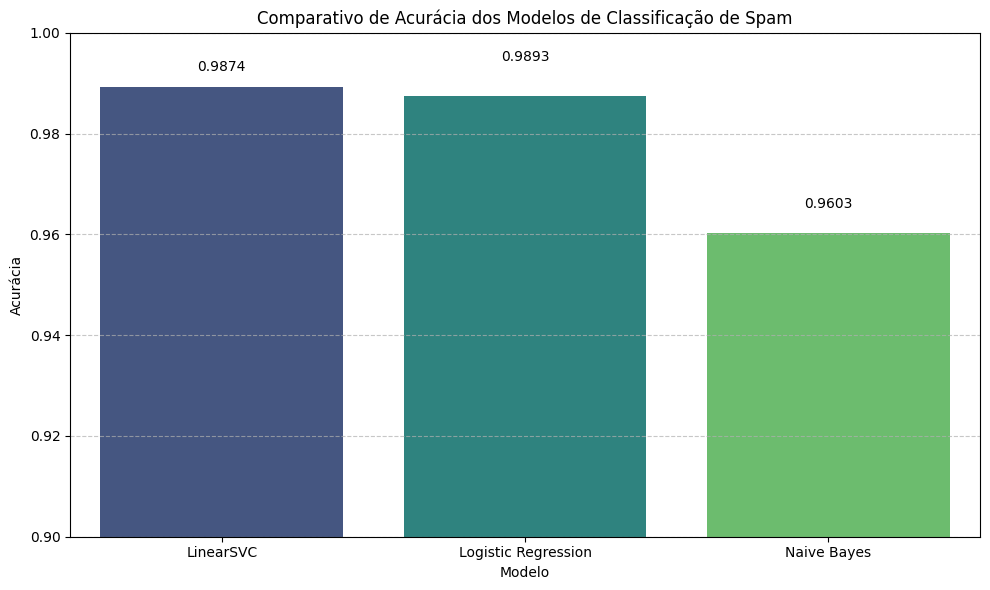

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
model_names = ['Logistic Regression', 'LinearSVC', 'Naive Bayes']
accuracies = [accuracy, accuracy_svm, accuracy_nb]

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Sort for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparativo de Acurácia dos Modelos de Classificação de Spam')
plt.xlabel('Modelo')
plt.ylabel('Acurácia')
plt.ylim(0.90, 1.0) # Set y-axis limits for better comparison

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.005, f'{row['Accuracy']:.4f}', color='black', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Análise do Gráfico de Acurácia

Este gráfico de barras ilustra claramente o desempenho relativo de cada modelo. Como observado anteriormente na conclusão textual, o **LinearSVC** se destaca com a maior acurácia, seguido de perto pela **Regressão Logística**. O **Naive Bayes**, embora ainda eficaz, apresenta uma acurácia ligeiramente inferior, corroborando a recomendação de que o LinearSVC é a escolha mais robusta para esta tarefa.

## Conclusão e Recomendação

A avaliação dos modelos de classificação de e-mails (HAM vs. SPAM) revelou os seguintes resultados de acurácia:

*   **LinearSVC**: 98.93%
*   **Regressão Logística**: 98.74%
*   **Naive Bayes**: 96.03%

Com base nas acurácias obtidas, o modelo **LinearSVC** apresentou o melhor desempenho geral, com 98.93% de acurácia. A Regressão Logística também se mostrou bastante eficaz, com uma acurácia muito próxima. O Naive Bayes, embora ainda com um bom desempenho, ficou ligeiramente abaixo dos outros dois modelos.

**Recomendação:**

Para esta tarefa de classificação de e-mails, o modelo **LinearSVC** é o mais recomendado, devido à sua acurácia superior. Em cenários onde a interpretabilidade é um fator crítico, a Regressão Logística poderia ser uma alternativa, dado seu desempenho quase idêntico. O Naive Bayes, por sua vez, pode ser considerado para casos onde a simplicidade computacional é primordial, mas à custa de uma ligeira queda na performance.